In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utilsCPD import *

def make_dynamic_blobs(n_samples, base_center, n_clusters, varying_features, 
                       cluster_std=1.0, center_offset_range=(-5, 5), 
                       distribution="normal", random_state=None):
    """
    Generate synthetic data with dynamic centers and feature-wise distributions.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like, shape (n_features,)
            Center of the base cluster.
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features that vary across clusters.
        cluster_std: float or array-like
            Std dev for distributions. Can be a scalar or array of shape (n_features,).
        center_offset_range: tuple
            Uniform offset range applied to varying features.
        distribution: str or list of str
            Single distribution name or list of length n_features specifying distribution per feature.
        random_state: int or None
            Seed for reproducibility.
    
    Returns:
        X: ndarray (n_samples, n_features)
        y: ndarray (n_samples,)
        centers: ndarray (n_clusters, n_features)
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    base_center = np.array(base_center, dtype=float)
    n_features = len(base_center)
    
    if isinstance(distribution, str):
        distribution = [distribution] * n_features
    elif isinstance(distribution, list):
        if len(distribution) != n_features:
            raise ValueError("Length of distribution list must match number of features.")

    if np.isscalar(cluster_std):
        cluster_std = np.full(n_features, cluster_std)

    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters

    # Generate cluster centers
    centers = [base_center.copy()]
    for _ in range(1, n_clusters):
        new_center = base_center.copy()
        for feat in varying_features:
            new_center[feat] += np.random.uniform(*center_offset_range)
        centers.append(new_center)
    centers = np.array(centers)

    # Generate data
    X = []
    y = []

    for cluster_idx, center in enumerate(centers):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        cluster_points = np.zeros((cluster_size, n_features), dtype=np.float32)

        for feat_idx in range(n_features):
            dist = distribution[feat_idx]
            std = cluster_std[feat_idx]
            loc = center[feat_idx]

            if dist == "normal":
                vals = np.random.normal(loc=loc, scale=std, size=cluster_size)
            elif dist == "uniform":
                vals = np.random.uniform(low=loc - std, high=loc + std, size=cluster_size)
            elif dist == "laplace":
                vals = np.random.laplace(loc=loc, scale=std, size=cluster_size)
            elif dist == "exponential":
                vals = np.random.exponential(scale=std, size=cluster_size) + loc
            elif dist == "beta":
                vals = np.random.beta(a=2, b=5, size=cluster_size) * std + loc
            elif dist == "gamma":
                vals = np.random.gamma(shape=2, scale=std, size=cluster_size) + loc
            else:
                raise ValueError(f"Unsupported distribution: {dist}")

            cluster_points[:, feat_idx] = vals
        
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)

    return np.vstack(X), np.array(y), centers


Text(0, 0.5, 'Abs diff Beta per removal')

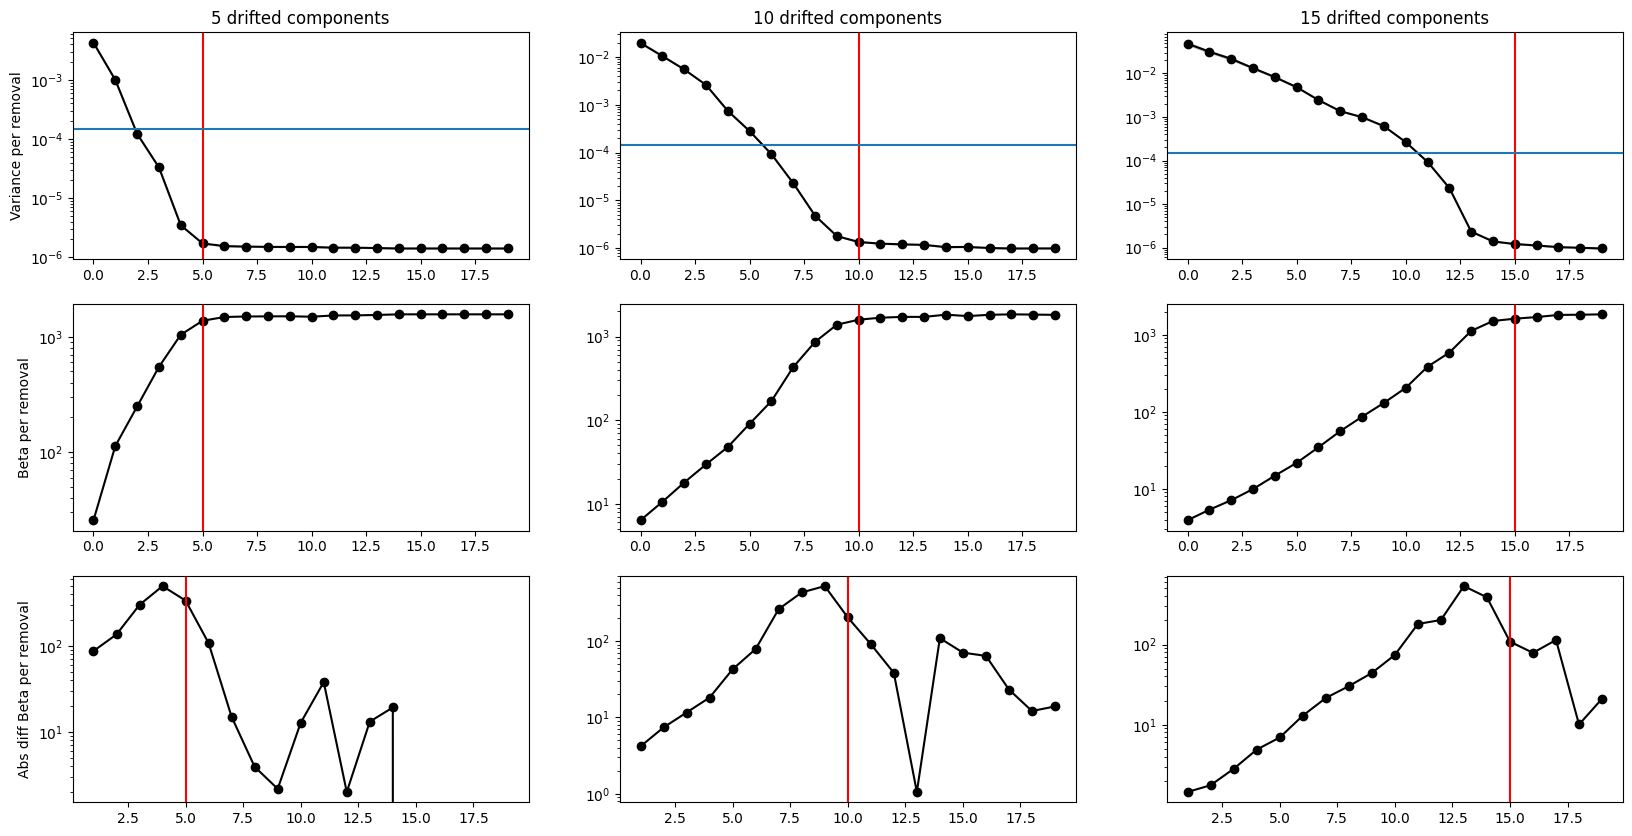

In [2]:

# Base center for the clusters

Dim = 30
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 1000
np.random.seed(0)
std= 0.4

fig, ax = plt.subplots(3,3,figsize=(20,10))
for row_ind, varying_dim in enumerate([5,10,15]):

    varying_features = np.random.choice(Dim,varying_dim,replace=False)  

    # # Plot the results
    # fig, ax = plt.subplots()
    # pd.DataFrame(X).plot(ax=ax, legend=False)
    # plt.show()


    VARS = {}
    BETAS = {}
    ALPHAS = {}
    for i in [0,1,2,3,4]:
        VARS[i] = []
        BETAS[i] = []
        ALPHAS[i]=[]
        
        X,y ,_ = make_dynamic_blobs(
        n_samples=n_samples, 
        base_center=base_center, 
        n_clusters=n_clusters, 
        varying_features=varying_features, 
        cluster_std=std, 
        center_offset_range=(-1, 1), 
        distribution=["normal"] * Dim + ["exponential"] * 0,
        random_state=i
    )
        x_tensor = torch.Tensor(X[:int(n_samples/2),:])
        y_tensor = torch.Tensor(X[int(n_samples/2):,:])
        rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,1000,q=0.95)

        # var = []
        # Bs = []
        # As = []
        for d in rfs:
            alph = d['alpha']
            b = d['beta']
            #print(alph/b**2)
            VARS[i].append(alph/b**2)
            BETAS[i].append(b)
            ALPHAS[i].append(alph)

    df_alpha = pd.DataFrame(ALPHAS)
    df_beta = pd.DataFrame(BETAS)

    vars = pd.DataFrame(df_alpha/(df_beta)**2)
    ax[0,row_ind].set_title(f"{varying_dim} drifted components")
    ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
    ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
    ax[0,row_ind].set_yscale('log')
    ax[0,row_ind].axvline(x=varying_dim,c='red')
    ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
#2*(std**2*Dim/Dim**2/500))
    #
    pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
    ax[2,row_ind].set_yscale('log')
    ax[2,row_ind].axvline(x=varying_dim,c='red')


    #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
    #ax[2].set_yscale('log')

    ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
    ax[1,row_ind].set_yscale('log')
    ax[1,row_ind].axvline(x=varying_dim,c='red')

ax[0,0].set_ylabel(f"Variance per removal")
ax[1,0].set_ylabel(f"Beta per removal")
ax[2,0].set_ylabel(f"Abs diff Beta per removal")


In [35]:
def get_feature_contribution(SL, theta,quantile_level,max=False):
    N = SL.shape[0]
    q_ind = int(np.floor(N*quantile_level))
    if max:
        return np.abs(theta[np.argsort(SL)[-1],:])
    thetas = theta[np.argsort(SL)[q_ind:],:]
    score = np.abs(thetas).mean(axis=0)
    #test= True
    #print(score)
    return score

def get_cov(x):
    return pd.DataFrame(x.numpy()).cov().to_numpy()

def op_norm(cov,p):
    return np.linalg.svd(cov,compute_uv=False)[0]**(p/2)


def remove_important_features_syn(X, Y, num_features_to_remove,N_Theta,max_parameter=False,q=0.95,p=2,device='cpu'):
    
    """
    Iteratively remove the most important features from X and Y
    and calculate new contributions at each step.
    
    X, Y: Data matrices with d columns (features).
    num_features_to_remove: Number of features to remove step by step.
    
    Returns:
    - A list of dictionaries containing removed feature index and new contributions.
    """
    betas = []
    removed_features = []  # To store removed feature indices and their contributions
    SWDs = []
    step = 1
    Y_imp = Y.clone().to(device)
    Contributions_out = []
    #THETA = sample_theta(X,N_Theta)
    THETA = sample_theta_torch(X,N_Theta,device=device)
    for _ in range(num_features_to_remove):
        #THETA = sample_theta_torch(X,N_Theta,device=device)
        dist = project_and_calc_dist_torch(X,Y_imp,THETA,p=p,device=device).mean(axis=0).detach().cpu().numpy()
        #print(f" var 1 {np.var(dist)}")
        #cov_x,cov_y = get_cov(X),get_cov(Y_imp)
        #OPX,OPY = op_norm(cov_x,2),op_norm(cov_y,2)
        #print(f"var bound {(OPX+OPY)**2}")

        Norm_diff = np.linalg.norm(X.mean(axis=0)-Y_imp.mean(axis=0))
        SWDs.append(dist.mean(axis=0))
        #print(SWDs)
        #print('removal: {}'.format(step))
        #print('SWD: {}'.format(dist.mean(axis=0)))
        #print('beta estimate: {}'.format(dist.mean(axis=0)/dist.var(axis=0,ddof=1)))
        betas.append(dist.mean(axis=0)/dist.var(axis=0,ddof=1))
        #print('alpha estimate: {}'.format(dist.mean(axis=0)**2/dist.var(axis=0,ddof=1)))
        # 1. Calculate feature contributions for the remaining features
        contributions = get_feature_contribution(dist,THETA.detach().cpu().numpy(),q,max=max_parameter)
        #print(contributions)
        # 2. Find the feature with the highest contribution
        max_contrib_index = np.argmax(contributions)
        #print(max_contrib_index)
        max_contrib_value = contributions[max_contrib_index]
        #print(contributions)
        # 3. Store the feature removal information
        removed_features.append({
            'removed_feature': max_contrib_index,
            'contribution_value': max_contrib_value,
            'beta': betas[-1],
            'alpha': dist.mean(axis=0)**2/dist.var(axis=0,ddof=1),
            'norm_diff':Norm_diff
        })
        # 4. Replace the feature from Y with mean value of X

        Y_imp[:,max_contrib_index] = X[:,max_contrib_index]#torch.ones(Y.shape[0]).to(device)*X[:,max_contrib_index].mean()
        Contributions_out.append(contributions)
        step+=1
    return removed_features,Contributions_out


In [16]:
np.linalg.norm(x_tensor.mean(axis=0)-y_tensor.mean(axis=0))

2.702568

Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished


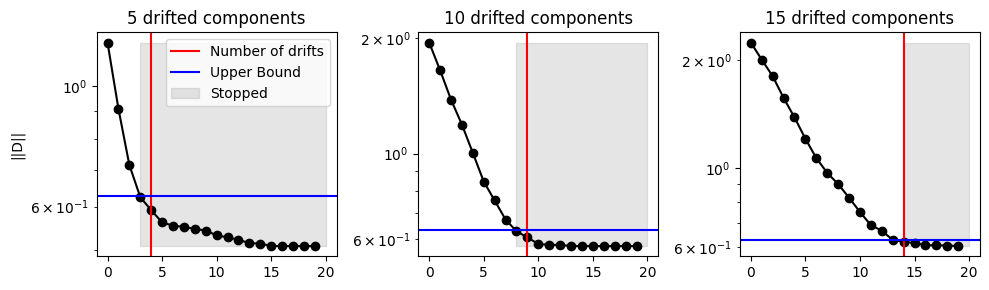

In [127]:
Dim = 50
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 500
np.random.seed(0)
std= 1.0

fig, ax = plt.subplots(1,3,figsize=(10,3))
for row_ind, varying_dim in enumerate([5,10,15]):

    varying_features = np.random.choice(Dim,varying_dim,replace=False)  

    # # Plot the results
    # fig, ax = plt.subplots()
    # pd.DataFrame(X).plot(ax=ax, legend=False)
    # plt.show()


    VARS = {}
    BETAS = {}
    ALPHAS = {}
    NORMDIFF = {}
    for i in [0,1,2,3,4]:
        VARS[i] = []
        BETAS[i] = []
        ALPHAS[i]=[]
        NORMDIFF[i] =[]
        
        X,y ,_ = make_dynamic_blobs(
        n_samples=n_samples, 
        base_center=base_center, 
        n_clusters=n_clusters, 
        varying_features=varying_features, 
        cluster_std=std, 
        center_offset_range=(-1, 1), 
        distribution=["normal"] * Dim + ["exponential"] * 0,
        random_state=i
    )
        x_tensor = torch.Tensor(X[:int(n_samples/2),:])
        y_tensor = torch.Tensor(X[int(n_samples/2):,:])
        rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,1000,q=0.95)
        print('Finished')

        # var = []
        # Bs = []
        # As = []
        #print(rfs)
        for d in rfs:
            alph = d['alpha']
            b = d['beta']
            normdiff = d['norm_diff']
            #print(alph/b**2)
            VARS[i].append(alph/b**2)
            BETAS[i].append(b)
            ALPHAS[i].append(alph)
            NORMDIFF[i].append(normdiff)

    df_alpha = pd.DataFrame(ALPHAS)
    df_beta = pd.DataFrame(BETAS)
    df_normdiff = pd.DataFrame(NORMDIFF)

    # vars = pd.DataFrame(df_alpha/(df_beta)**2)
    ax[row_ind].set_title(f"{varying_dim} drifted components")
    # ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
    # ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
    # ax[0,row_ind].set_yscale('log')
    # ax[0,row_ind].axvline(x=varying_dim,c='red')
    #ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
#2*(std**2*Dim/Dim**2/500))
    #
    #pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
    ax[row_ind].plot(df_normdiff.mean(axis=1),marker="o",c='black')
    ax[row_ind].set_yscale('log')
    ax[row_ind].axvline(x=varying_dim-1,c='red',alpha=1.0,label='Number of drifts')
    UPPER = (2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5
    mask = (UPPER > df_normdiff.mean(axis=1))

    for ind,m in enumerate(mask):
        if m:
            termination = ind
            break
    ax[row_ind].axhline((2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5, label='Upper Bound',c='blue')
    ax[row_ind].fill_betweenx(np.linspace(df_normdiff.mean(axis=1).min(),df_normdiff.mean(axis=1).max(),100),termination,len(df_normdiff.mean(axis=1)),color='grey',alpha=0.2,label='Stopped')
    #ax[row_ind].fill_betweenx()

    #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
    #ax[2].set_yscale('log')

    # ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
    # ax[1,row_ind].set_yscale('log')
    # ax[1,row_ind].axvline(x=varying_dim,c='red')

ax[0].set_ylabel(f"||D||")
fig.tight_layout()
ax[0].legend(loc=1)
#ax[1,0].set_ylabel(f"Beta per removal")
#ax[2,0].set_ylabel(f"Abs diff Beta per removal")

Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished


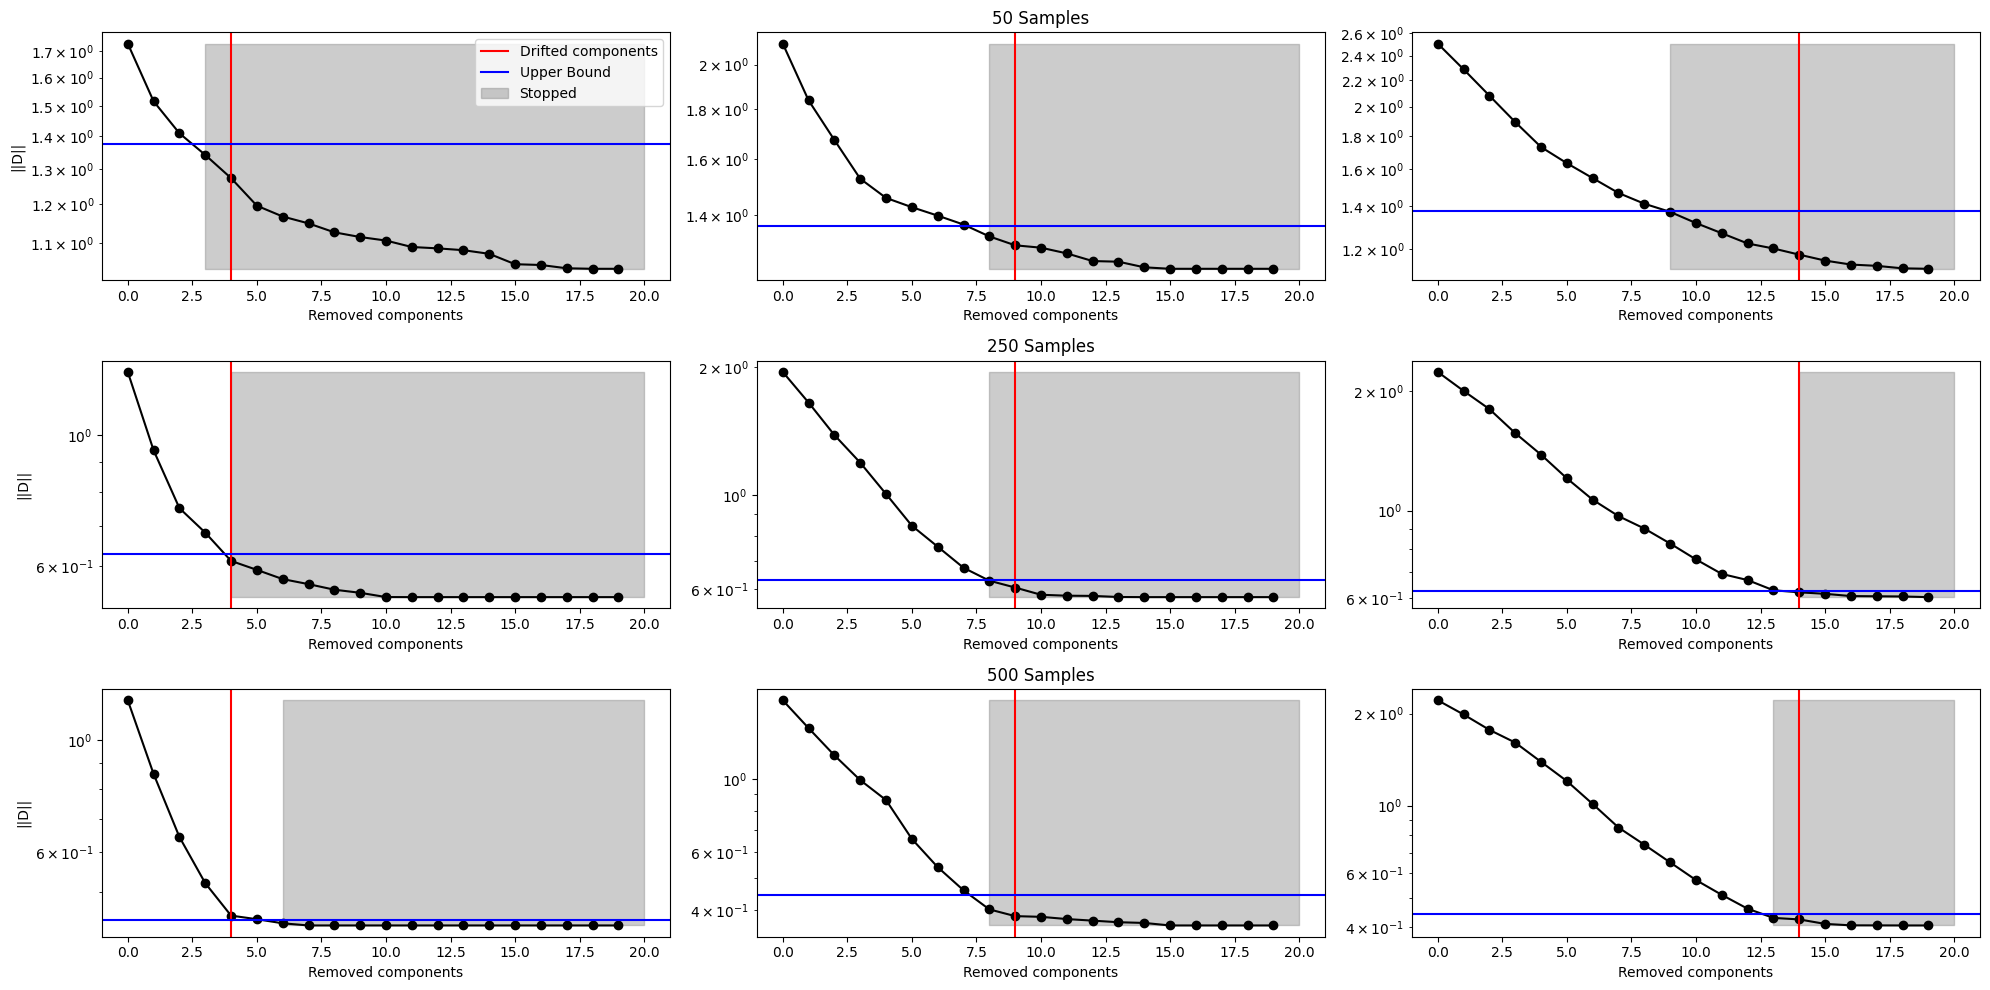

In [138]:
Dim = 50
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 500
np.random.seed(0)
std= 1.0


fig, ax = plt.subplots(3,3,figsize=(20,10))
for row_idx ,n_samples in enumerate([100,500,1000]):
    for col_idx, varying_dim in enumerate([5,10,15]):

        varying_features = np.random.choice(Dim,varying_dim,replace=False)  

        # # Plot the results
        # fig, ax = plt.subplots()
        # pd.DataFrame(X).plot(ax=ax, legend=False)
        # plt.show()


        VARS = {}
        BETAS = {}
        ALPHAS = {}
        NORMDIFF = {}
        for i in [0,1,2,3,4]:
            VARS[i] = []
            BETAS[i] = []
            ALPHAS[i]=[]
            NORMDIFF[i] =[]
            
            X,y ,_ = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=std, 
            center_offset_range=(-1, 1), 
            distribution=["normal"] * Dim + ["exponential"] * 0,
            random_state=i
        )
            x_tensor = torch.Tensor(X[:int(n_samples/2),:])
            y_tensor = torch.Tensor(X[int(n_samples/2):,:])
            rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,1000,q=0.95)
            print('Finished')

            # var = []
            # Bs = []
            # As = []
            #print(rfs)
            for d in rfs:
                alph = d['alpha']
                b = d['beta']
                normdiff = d['norm_diff']
                #print(alph/b**2)
                VARS[i].append(alph/b**2)
                BETAS[i].append(b)
                ALPHAS[i].append(alph)
                NORMDIFF[i].append(normdiff)

        df_alpha = pd.DataFrame(ALPHAS)
        df_beta = pd.DataFrame(BETAS)
        df_normdiff = pd.DataFrame(NORMDIFF)

        # vars = pd.DataFrame(df_alpha/(df_beta)**2)

        ax[row_idx,1].set_title(f"{n_samples/2:.0f} Samples")
        # ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
        # ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
        # ax[0,row_ind].set_yscale('log')
        # ax[0,row_ind].axvline(x=varying_dim,c='red')
        #ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
    #2*(std**2*Dim/Dim**2/500))
        #
        #pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
        ax[row_idx,col_idx].plot(df_normdiff.mean(axis=1),marker="o",c='black')
        ax[row_idx,col_idx].set_yscale('log')
        ax[row_idx,col_idx].set_xlabel('Removed components')
        ax[row_idx,col_idx].axvline(x=varying_dim-1,c='red',alpha=1.0,label='Drifted components')
        UPPER = (2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5
        mask = (UPPER > df_normdiff.mean(axis=1))

        for ind,m in enumerate(mask):
            if m:
                termination = ind
                break
        ax[row_idx,col_idx].axhline((2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5, label='Upper Bound',c='blue')
        ax[row_idx,col_idx].fill_betweenx(np.linspace(df_normdiff.mean(axis=1).min(),df_normdiff.mean(axis=1).max(),100),termination,len(df_normdiff.mean(axis=1)),color='grey',alpha=0.4,label='Stopped')
        #ax[row_ind].fill_betweenx()

        #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
        #ax[2].set_yscale('log')

        # ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
        # ax[1,row_ind].set_yscale('log')
        # ax[1,row_ind].axvline(x=varying_dim,c='red')

    ax[row_idx,0].set_ylabel(f"||D||")
    fig.tight_layout()
    ax[0,0].legend(loc=1)
    #ax[1,0].set_ylabel(f"Beta per removal")
    #ax[2,0].set_ylabel(f"Abs diff Beta per removal")

Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished


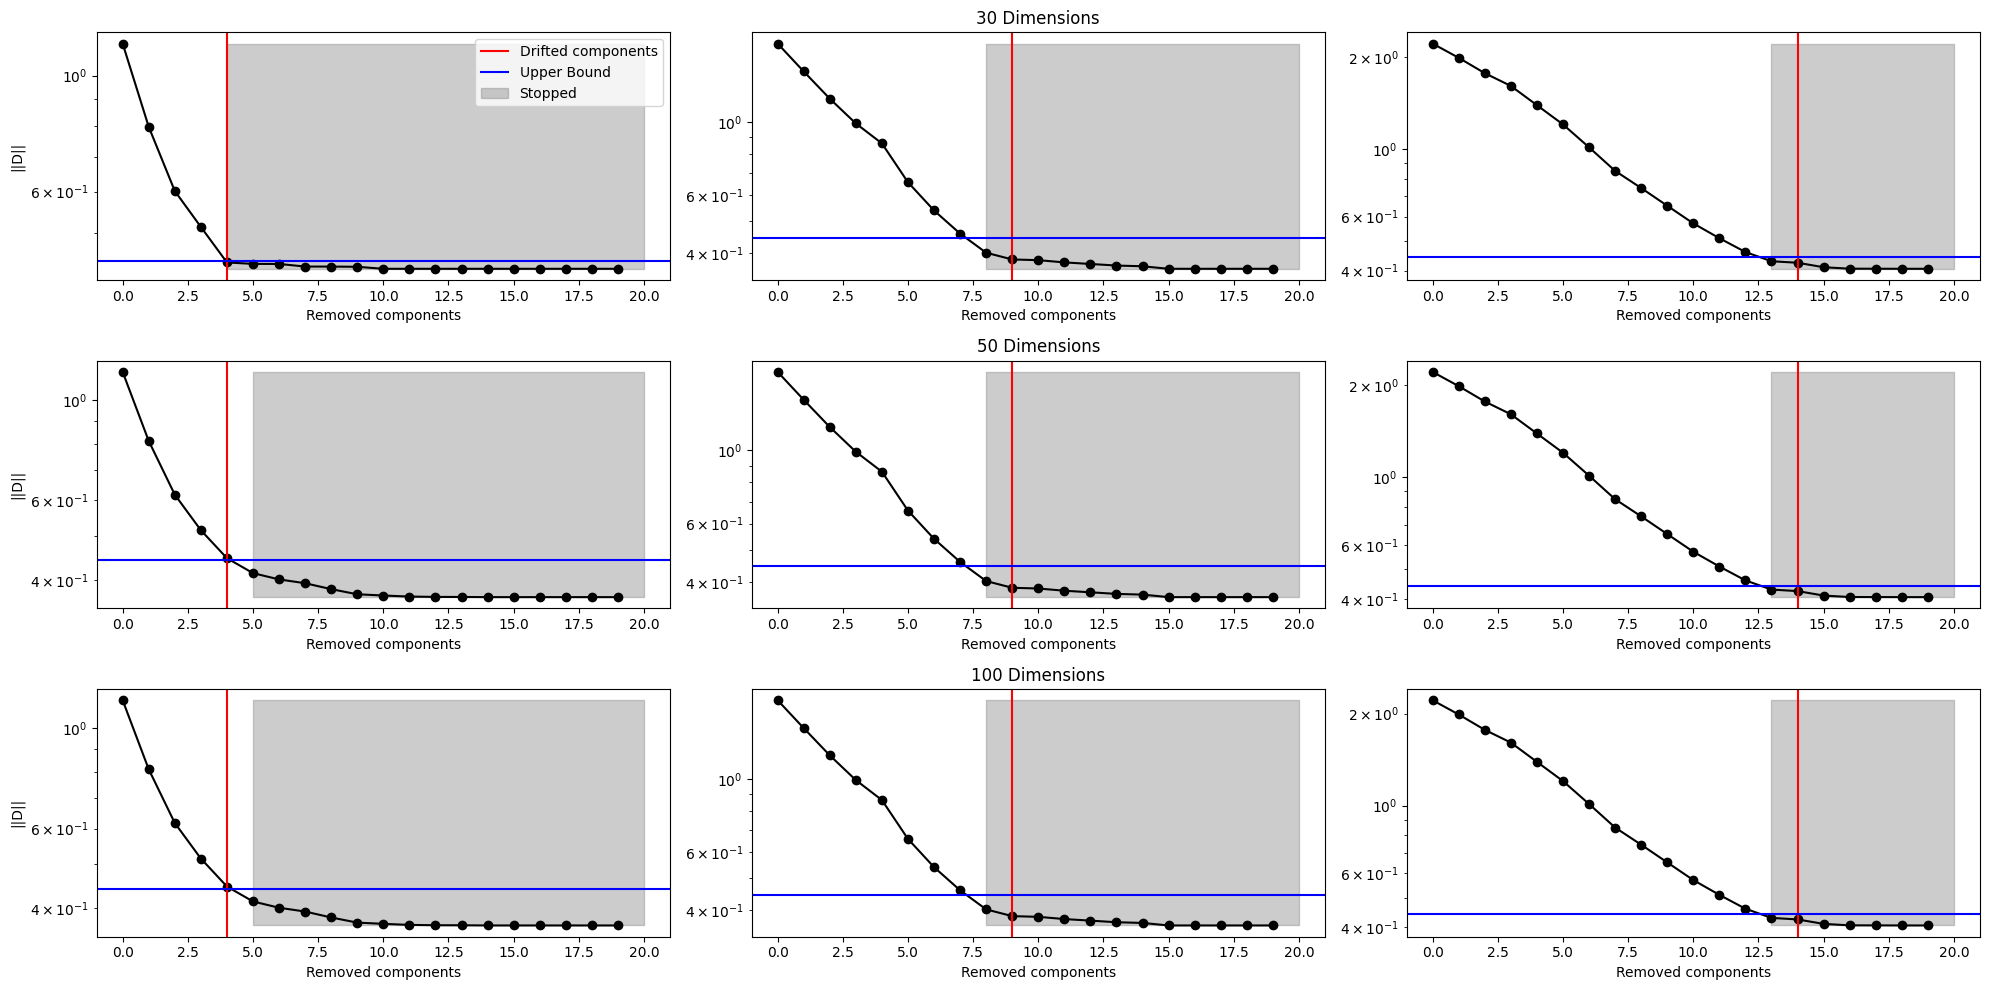

In [139]:
Dim = 50
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 1000
np.random.seed(0)
std= 1.0


fig, ax = plt.subplots(3,3,figsize=(20,10))
for row_idx ,dim in enumerate([30,50,100]):
    for col_idx, varying_dim in enumerate([5,10,15]):

        varying_features = np.random.choice(Dim,varying_dim,replace=False)  

        # # Plot the results
        # fig, ax = plt.subplots()
        # pd.DataFrame(X).plot(ax=ax, legend=False)
        # plt.show()


        VARS = {}
        BETAS = {}
        ALPHAS = {}
        NORMDIFF = {}
        for i in [0,1,2,3,4]:
            VARS[i] = []
            BETAS[i] = []
            ALPHAS[i]=[]
            NORMDIFF[i] =[]
            
            X,y ,_ = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=std, 
            center_offset_range=(-1, 1), 
            distribution=["normal"] * Dim + ["exponential"] * 0,
            random_state=i
        )
            x_tensor = torch.Tensor(X[:int(n_samples/2),:])
            y_tensor = torch.Tensor(X[int(n_samples/2):,:])
            rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,1000,q=0.95)
            print('Finished')

            # var = []
            # Bs = []
            # As = []
            #print(rfs)
            for d in rfs:
                alph = d['alpha']
                b = d['beta']
                normdiff = d['norm_diff']
                #print(alph/b**2)
                VARS[i].append(alph/b**2)
                BETAS[i].append(b)
                ALPHAS[i].append(alph)
                NORMDIFF[i].append(normdiff)

        df_alpha = pd.DataFrame(ALPHAS)
        df_beta = pd.DataFrame(BETAS)
        df_normdiff = pd.DataFrame(NORMDIFF)

        # vars = pd.DataFrame(df_alpha/(df_beta)**2)

        ax[row_idx,1].set_title(f"{dim:.0f} Dimensions")
        # ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
        # ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
        # ax[0,row_ind].set_yscale('log')
        # ax[0,row_ind].axvline(x=varying_dim,c='red')
        #ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
    #2*(std**2*Dim/Dim**2/500))
        #
        #pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
        ax[row_idx,col_idx].plot(df_normdiff.mean(axis=1),marker="o",c='black')
        ax[row_idx,col_idx].set_yscale('log')
        ax[row_idx,col_idx].set_xlabel('Removed components')
        ax[row_idx,col_idx].axvline(x=varying_dim-1,c='red',alpha=1.0,label='Drifted components')
        UPPER = (2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5
        mask = (UPPER > df_normdiff.mean(axis=1))

        for ind,m in enumerate(mask):
            if m:
                termination = ind
                break
        ax[row_idx,col_idx].axhline((2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5, label='Upper Bound',c='blue')
        ax[row_idx,col_idx].fill_betweenx(np.linspace(df_normdiff.mean(axis=1).min(),df_normdiff.mean(axis=1).max(),100),termination,len(df_normdiff.mean(axis=1)),color='grey',alpha=0.4,label='Stopped')
        #ax[row_ind].fill_betweenx()

        #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
        #ax[2].set_yscale('log')

        # ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
        # ax[1,row_ind].set_yscale('log')
        # ax[1,row_ind].axvline(x=varying_dim,c='red')

    ax[row_idx,0].set_ylabel(f"||D||")
    fig.tight_layout()
    ax[0,0].legend(loc=1)
    #ax[1,0].set_ylabel(f"Beta per removal")
    #ax[2,0].set_ylabel(f"Abs diff Beta per removal")

Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished


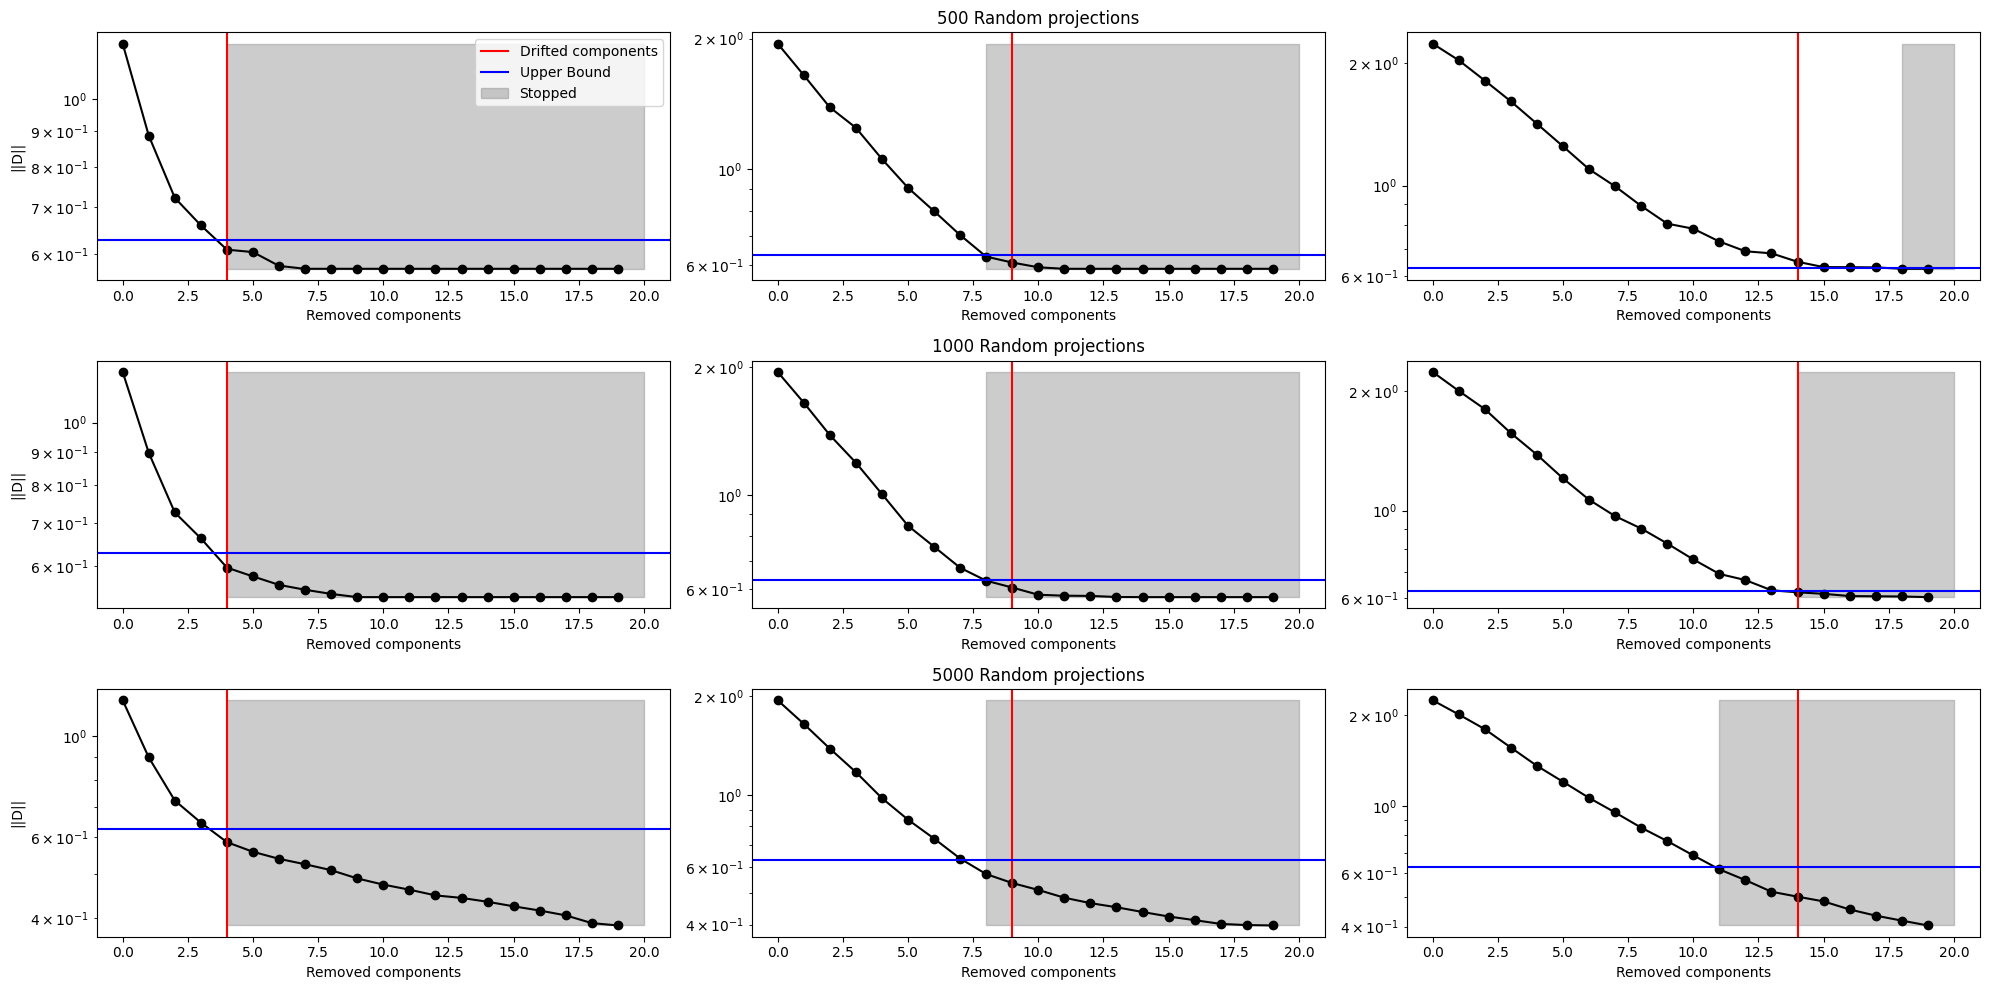

In [149]:
Dim = 50
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 500
np.random.seed(0)
std= 1.0


fig, ax = plt.subplots(3,3,figsize=(20,10))
for row_idx ,L in enumerate([500,1000,5000]):
    for col_idx, varying_dim in enumerate([5,10,15]):

        varying_features = np.random.choice(Dim,varying_dim,replace=False)  

        # # Plot the results
        # fig, ax = plt.subplots()
        # pd.DataFrame(X).plot(ax=ax, legend=False)
        # plt.show()


        VARS = {}
        BETAS = {}
        ALPHAS = {}
        NORMDIFF = {}
        for i in [0,1,2,3,4]:
            VARS[i] = []
            BETAS[i] = []
            ALPHAS[i]=[]
            NORMDIFF[i] =[]
            
            X,y ,_ = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=std, 
            center_offset_range=(-1, 1), 
            distribution=["normal"] * Dim + ["exponential"] * 0,
            random_state=i
        )
            x_tensor = torch.Tensor(X[:int(n_samples/2),:])
            y_tensor = torch.Tensor(X[int(n_samples/2):,:])
            rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,L,q=0.95)
            print('Finished')

            # var = []
            # Bs = []
            # As = []
            #print(rfs)
            for d in rfs:
                alph = d['alpha']
                b = d['beta']
                normdiff = d['norm_diff']
                #print(alph/b**2)
                VARS[i].append(alph/b**2)
                BETAS[i].append(b)
                ALPHAS[i].append(alph)
                NORMDIFF[i].append(normdiff)

        df_alpha = pd.DataFrame(ALPHAS)
        df_beta = pd.DataFrame(BETAS)
        df_normdiff = pd.DataFrame(NORMDIFF)

        # vars = pd.DataFrame(df_alpha/(df_beta)**2)

        ax[row_idx,1].set_title(f"{L} Random projections")
        # ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
        # ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
        # ax[0,row_ind].set_yscale('log')
        # ax[0,row_ind].axvline(x=varying_dim,c='red')
        #ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
    #2*(std**2*Dim/Dim**2/500))
        #
        #pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
        ax[row_idx,col_idx].plot(df_normdiff.mean(axis=1),marker="o",c='black')
        ax[row_idx,col_idx].set_yscale('log')
        ax[row_idx,col_idx].set_xlabel('Removed components')
        ax[row_idx,col_idx].axvline(x=varying_dim-1,c='red',alpha=1.0,label='Drifted components')
        UPPER = (2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5
        mask = (UPPER > df_normdiff.mean(axis=1))

        for ind,m in enumerate(mask):
            if m:
                termination = ind
                break
        ax[row_idx,col_idx].axhline((2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5, label='Upper Bound',c='blue')
        ax[row_idx,col_idx].fill_betweenx(np.linspace(df_normdiff.mean(axis=1).min(),df_normdiff.mean(axis=1).max(),100),termination,len(df_normdiff.mean(axis=1)),color='grey',alpha=0.4,label='Stopped')
        #ax[row_ind].fill_betweenx()

        #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
        #ax[2].set_yscale('log')

        # ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
        # ax[1,row_ind].set_yscale('log')
        # ax[1,row_ind].axvline(x=varying_dim,c='red')

    ax[row_idx,0].set_ylabel(f"||D||")
    fig.tight_layout()
    ax[0,0].legend(loc=1)
    #ax[1,0].set_ylabel(f"Beta per removal")
    #ax[2,0].set_ylabel(f"Abs diff Beta per removal")

Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished
Finished


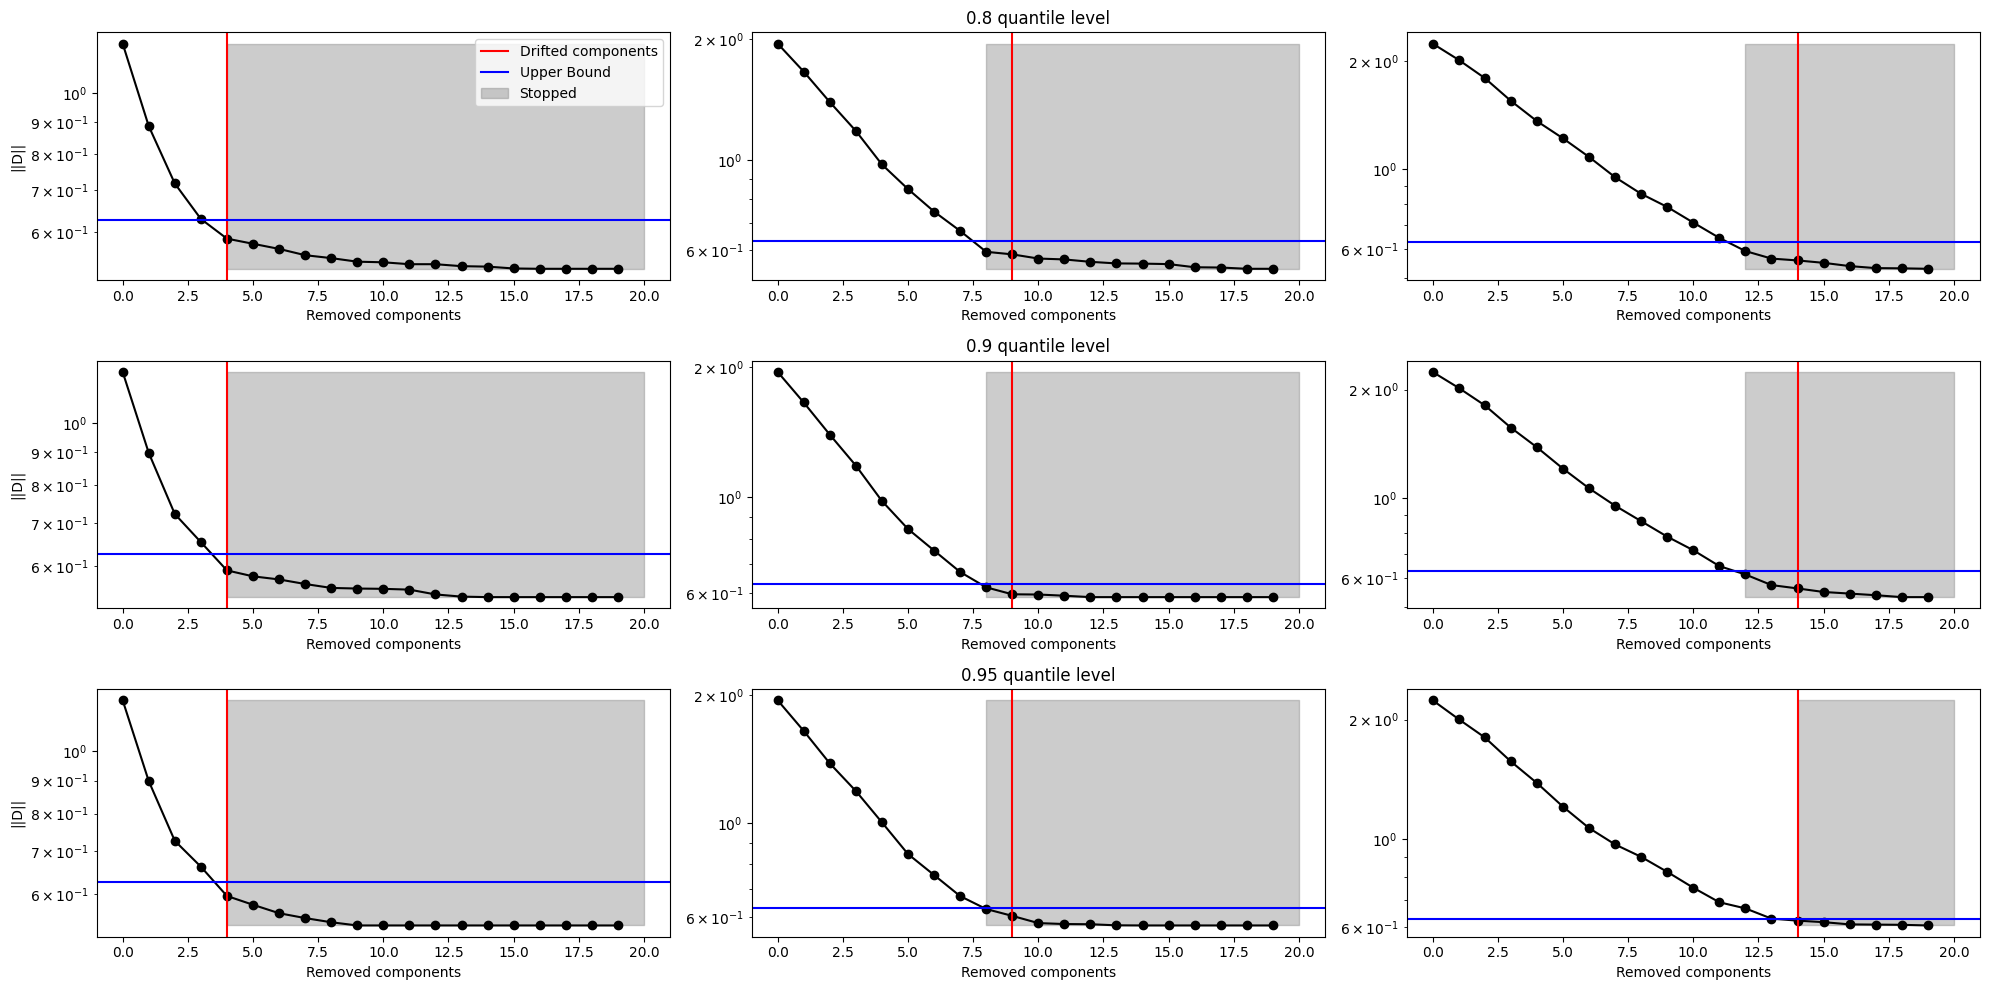

In [150]:
Dim = 50
base_center = list(np.random.uniform(-3, 3, Dim))  
n_clusters = 2
n_samples = 500
np.random.seed(0)
std= 1.0


fig, ax = plt.subplots(3,3,figsize=(20,10))
for row_idx ,q in enumerate([0.8,0.9,0.95]):
    for col_idx, varying_dim in enumerate([5,10,15]):

        varying_features = np.random.choice(Dim,varying_dim,replace=False)  

        # # Plot the results
        # fig, ax = plt.subplots()
        # pd.DataFrame(X).plot(ax=ax, legend=False)
        # plt.show()


        VARS = {}
        BETAS = {}
        ALPHAS = {}
        NORMDIFF = {}
        for i in [0,1,2,3,4]:
            VARS[i] = []
            BETAS[i] = []
            ALPHAS[i]=[]
            NORMDIFF[i] =[]
            
            X,y ,_ = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_center, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=std, 
            center_offset_range=(-1, 1), 
            distribution=["normal"] * Dim + ["exponential"] * 0,
            random_state=i
        )
            x_tensor = torch.Tensor(X[:int(n_samples/2),:])
            y_tensor = torch.Tensor(X[int(n_samples/2):,:])
            rfs, _ = remove_important_features_syn(x_tensor,y_tensor,20,1000,q=q)
            print('Finished')

            # var = []
            # Bs = []
            # As = []
            #print(rfs)
            for d in rfs:
                alph = d['alpha']
                b = d['beta']
                normdiff = d['norm_diff']
                #print(alph/b**2)
                VARS[i].append(alph/b**2)
                BETAS[i].append(b)
                ALPHAS[i].append(alph)
                NORMDIFF[i].append(normdiff)

        df_alpha = pd.DataFrame(ALPHAS)
        df_beta = pd.DataFrame(BETAS)
        df_normdiff = pd.DataFrame(NORMDIFF)

        # vars = pd.DataFrame(df_alpha/(df_beta)**2)

        ax[row_idx,1].set_title(f"{q} quantile level")
        # ax[0,row_ind].plot(vars.mean(axis=1),marker="o",c='black')
        # ax[0,row_ind].fill_between(range(len(vars)),vars.mean(axis=1)-2*vars.var(axis=1),vars.mean(axis=1)+2*vars.var(axis=1),alpha=0.2,color='black')
        # ax[0,row_ind].set_yscale('log')
        # ax[0,row_ind].axvline(x=varying_dim,c='red')
        #ax[0,row_ind].axhline((x_tensor**2).var(axis=0).sum()/Dim**2/n_samples+(y_tensor**2).var(axis=0).sum()/Dim**2/n_samples)#2*(2*std**2)/(Dim*(n_samples/2)))
    #2*(std**2*Dim/Dim**2/500))
        #
        #pd.DataFrame((df_beta.mean(axis=1))).diff().abs().plot(ax=ax[2,row_ind],marker='o',c='black',legend=False)
        ax[row_idx,col_idx].plot(df_normdiff.mean(axis=1),marker="o",c='black')
        ax[row_idx,col_idx].set_yscale('log')
        ax[row_idx,col_idx].set_xlabel('Removed components')
        ax[row_idx,col_idx].axvline(x=varying_dim-1,c='red',alpha=1.0,label='Drifted components')
        UPPER = (2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5
        mask = (UPPER > df_normdiff.mean(axis=1))

        for ind,m in enumerate(mask):
            if m:
                termination = ind
                break
        ax[row_idx,col_idx].axhline((2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5, label='Upper Bound',c='blue')
        ax[row_idx,col_idx].fill_betweenx(np.linspace(df_normdiff.mean(axis=1).min(),df_normdiff.mean(axis=1).max(),100),termination,len(df_normdiff.mean(axis=1)),color='grey',alpha=0.4,label='Stopped')
        #ax[row_ind].fill_betweenx()

        #pd.DataFrame(np.array(Bs)).pct_change().plot(ax=ax[2],marker='o')
        #ax[2].set_yscale('log')

        # ax[1,row_ind].plot(df_beta.mean(axis=1),marker='o',c='black')
        # ax[1,row_ind].set_yscale('log')
        # ax[1,row_ind].axvline(x=varying_dim,c='red')

    ax[row_idx,0].set_ylabel(f"||D||")
    fig.tight_layout()
    ax[0,0].legend(loc=1)
    #ax[1,0].set_ylabel(f"Beta per removal")
    #ax[2,0].set_ylabel(f"Abs diff Beta per removal")

In [58]:
(2*np.linalg.svd(get_cov(x_tensor),compute_uv=False).sum()/(n_samples/2))**0.5

0.07685745645122041